In [31]:
#Si estas en colab, corre esta celda para instalar las librerias
!pip install qiskit
!pip install pylatexenc
!pip install qiskit-aer

"pip" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


"pip" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
"pip" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


# Sesión 8 Laboratorio de Computación Cuántica 2

## Caminatas cuánticas

### Caminata aleatoria discreta

En la física estadística, existe el concepto de las llamadas caminatas aleatorias. La clave detrás de este concepto es que tienes un objeto (el caminante aleatorio) cuya posición varía en función de lo que un item (la moneda) ordene. 

Imagina que el caminante inicia en posición x=0 y se mueve según como una moneda ordene, entonces tienes 2 posibilidades: Que avance, o que retroceda 1 paso. Un modelo muy simple de caminante aleatorio es este:

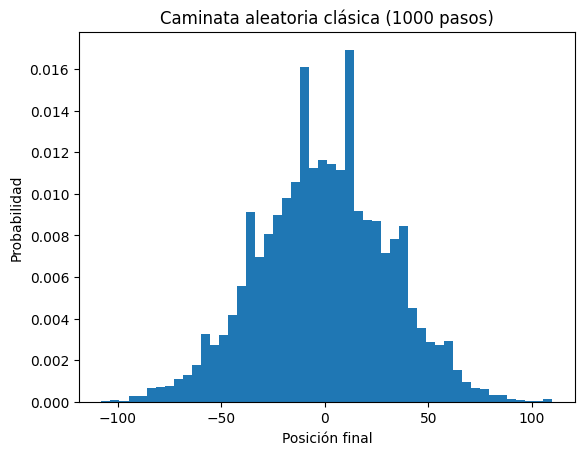

In [62]:
import numpy as np
import matplotlib.pyplot as plt

num_steps = 1000
num_walks = 10000   

final_positions = []

for _ in range(num_walks):
    position = 0
    for _ in range(num_steps):
        step = np.random.choice([-1, 1])  
        position += step
    final_positions.append(position)


plt.hist(final_positions, bins=50, density=True)
plt.title(f"Caminata aleatoria clásica ({num_steps} pasos)")
plt.xlabel("Posición final")
plt.ylabel("Probabilidad")
plt.show()

En una caminata aleatoria, la posición final del caminante aleatorio forma una gaussiana con varianza $\sigma^2=t$ donde t es el tiempo que en esta ocasión esta asociado al número de pasos que el caminante da en el sistema

### Generalización Cuántica




Una caminata cuántica es el análogo cuántico de una caminata aleatoria clásica, donde la evolución del sistema ocurre mediante superposición e interferencia en lugar de probabilidades clásicas. Igual funciona con superposición de posiciones y una moneda cuántica. Pasare a explicar varios conceptos importantes antes de pasar a la lógica de las caminatas cuánticas



#### Espacio de Hilbert

El sistema vive en un espacio tensorial:

$$
\mathcal{H} = \mathcal{H}_{pos} \otimes \mathcal{H}_{coin}
$$

#### Espacio de posición

$$
\mathcal{H}_{pos} = \text{span}\{ |x\rangle : x \in \mathbb{Z} \}
$$

Representa la posición de la partícula.



####  Espacio de coin (o moneda)

$$
\mathcal{H}_{coin} = \text{span}\{ |0\rangle, |1\rangle \}
$$

Interpretación:
- $|0\rangle$: izquierda  
- $|1\rangle$: derecha  



#### Estado general

$$
|\psi\rangle = \sum_x \left( a_x |x\rangle|0\rangle + b_x |x\rangle|1\rangle \right)
$$





### Logica de las caminatas cuanticas e interpretación del estado

En la caminata cuántica con la que vayamos a trabajar, buscamos simular una dinamica muy similar a la caminata clásica aleatoria pero con multiples caminantes que surgen conforme la dinamica de la caminata se va manifestando, generando superposición sobre si mismo

Si la particula esta en el estado $|x\rangle|c\rangle$, esto representa que

> "La partícula está en la posición $x$ y tiene la instrucción $c$"

La moneda nos indica la orden de movimiento que le vamos a dar al caminante, y



### Dinámica de la caminata

Cada paso consta de dos operadores, el operador de coin y el operador de shift. El primero describe como son las instrucciones de movimiento, el segundo, la naturaleza del movimiento



#### Operador de coin

Se aplica un operador unitario sobre el coin que nos describe como será la instrucción de movimiento del caminante, lo denominamos $C$

Ejemplo: $C=H$ Hadamard

$$
H =
\frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}
$$

Acción:

$$
H|0\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}
$$

Este operador crea superposición de direcciones.



#### Operador de shift

El operador de shift mueve la posición condicionado al coin:

$$
S =
\sum_x \Big(
|x-1\rangle\langle x| \otimes |0\rangle\langle 0|
+
|x+1\rangle\langle x| \otimes |1\rangle\langle 1|
\Big)
$$

Acción:

$$
|x\rangle|0\rangle \to |x-1\rangle|0\rangle
$$

$$
|x\rangle|1\rangle \to |x+1\rangle|1\rangle
$$



#### Operador de la caminata

Para realizar un paso, se aplica primero el operador de coin al subespacio de la moneda, para posteriormente generar el movimiento utilizando la moneda

$$
U = S (I \otimes C)
$$





### Ejemplo de caminata cuántica

Visualicemos todo lo que hemos trabajado en un ejemplo diáctico que muestre una evolución de estado de la caminata aleatoria

#### Estado inicial

$$
|\psi_0\rangle = |0\rangle|0\rangle
$$



#### Paso 1

Después del coin:

$$
\frac{1}{\sqrt{2}}(|0\rangle|0\rangle + |0\rangle|1\rangle)
$$

Después del shift:

$$
\frac{1}{\sqrt{2}}(|-1\rangle|0\rangle + |1\rangle|1\rangle)
$$



#### Paso 2

$$
|\psi_2\rangle =
\frac{1}{2}(
|-2\rangle|0\rangle
+ |0\rangle|1\rangle
+ |0\rangle|0\rangle
- |2\rangle|1\rangle
)
$$


#### Medición

La probabilidad de encontrar la partícula en la posición $x$ es:

$$
P(x) = \sum_{c \in \{0,1\}} |\langle x,c | \psi \rangle|^2
$$




In [87]:
import numpy as np
import matplotlib.pyplot as plt

In [88]:
N = 20  # posiciones: [-5, ..., 5]
size = 2*N + 1

In [89]:
H = (1/np.sqrt(2)) * np.array([ # operador de Hadamard
    [1, 1],
    [1, -1]
])

I_pos = np.eye(size) # identidad para el espacio de posiciones
H_total = np.kron(H, I_pos) # operador total: Hadamard en el espacio de coin y identidad en el espacio de posiciones

In [90]:
S = np.zeros((2*size, 2*size))# operador shift

for x in range(size):
    left = x - 1
    right = x + 1

    # moneda = |0> → izquierda
    if left >= 0:
        S[left, x] = 1

    # moneda = |1> → derecha
    if right < size:
        S[size + right, size + x] = 1

In [91]:
U = S @ H_total # operador de evolución total: primero aplica el Hadamard, luego el shift

In [92]:
psi = np.zeros(2*size)
psi[N] = 1  # moneda = |0>, posición = 0

In [93]:
steps = 8

for _ in range(steps):
    psi = U @ psi

In [94]:
prob = np.zeros(size)

for x in range(size):
    prob[x] = np.abs(psi[x])**2 + np.abs(psi[size + x])**2

print(prob)

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.00390625 0.         0.1953125  0.         0.4140625  0.
 0.1015625  0.         0.0703125  0.         0.0703125  0.
 0.0390625  0.         0.1015625  0.         0.00390625 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.        ]


In [95]:
def position_distribution(psi, N):
    size = 2*N + 1
    prob = np.zeros(size)
    
    for x in range(size):
        prob[x] = np.abs(psi[x])**2 + np.abs(psi[size + x])**2
    
    positions = np.arange(-N, N+1)
    
    return positions, prob


positions, prob = position_distribution(psi, N)


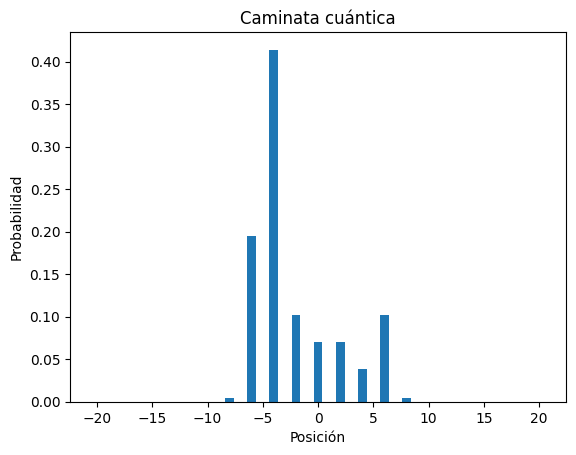

In [96]:
plt.bar(positions, prob)
plt.xlabel("Posición")
plt.ylabel("Probabilidad")
plt.title("Caminata cuántica")
plt.show()

### References

The explanations, code, examples, exercises, and pedagogical presentation in this notebook were written by Benjamín Sánchez Hernández.

The following sources were used as references for the theoretical background, notation, implementation choices, and supplementary consultation:

1. Salvador E. Venegas-Andraca. *Quantum Walks for Computer Scientists*. Synthesis Lectures on Quantum Computing, Morgan & Claypool Publishers, 2008.  
   Used as a theoretical and pedagogical reference for discrete-time quantum walks, coined quantum walks, the role of the coin operator, and the construction of quantum walk dynamics.

2. Salvador E. Venegas-Andraca. *Quantum walks: a comprehensive review*. Quantum Information Processing, 11, 1015–1106, 2012.  
   Used as a supplementary theoretical reference for the foundations of discrete-time and continuous-time quantum walks, their relation to classical random walks, and their role in quantum computation.  
   https://arxiv.org/abs/1201.4780

3. Dorit Aharonov, Andris Ambainis, Julia Kempe, and Umesh Vazirani. *Quantum Walks on Graphs*. Proceedings of the 33rd Annual ACM Symposium on Theory of Computing, 2001.  
   Used as a foundational reference for the formal study of quantum walks on graphs and their comparison with classical random walks.  
   https://arxiv.org/abs/quant-ph/0012090

4. Peter G. Doyle and J. Laurie Snell. *Random Walks and Electric Networks*. Mathematical Association of America, 1984.  
   Used as a background reference for classical random walks.  
   https://arxiv.org/abs/math/0001057

5. NumPy Developers. *NumPy Documentation*.  
   Used as technical reference for numerical array operations and matrix-based simulation.  
   https://numpy.org/doc/

6. Matplotlib Developers. *Matplotlib Documentation*.  
   Used as technical reference for plotting probability distributions.  
   https://matplotlib.org/stable/